## The Dataset: IMDb Movie Reviews

The **IMDb dataset** is a large collection of movie reviews from the Internet
Movie Database, commonly used as a benchmark for binary sentiment classification.

### What's in it

- **50,000 reviews total**, split evenly into a **25,000-review training set**
  and a **25,000-review test set**.
- Each split is itself **perfectly balanced**: 12,500 positive reviews and
  12,500 negative reviews, so `train_df['label'].value_counts()` and
  `test_df['label'].value_counts()` both come out 50/50.
- Two columns matter here: **`text`** — the full, raw review as written by the
  user (unprocessed natural language, not yet encoded into numbers) — and
  **`label`** — a binary sentiment tag, `1` for positive and `0` for negative.
- There's also a third, unlabeled `unsupervised` split (50,000 additional
  reviews with no sentiment label) bundled with the dataset on the Hub, but
  it isn't loaded here since `train_df`/`test_df` only pull from `'train'`
  and `'test'`.

### Why this dataset fits this exercise

- **It's already a genuine text classification problem**, so the raw `text`
  column is a natural target for building a text-encoding pipeline (BoW,
  TF-IDF, or embeddings) into features before training a classifier — the same
  kind of pipeline explored earlier in this series.
- **Its natural balance is exactly what makes it useful here as a base for an
  artificial imbalance experiment.** Since the real IMDb train split starts at
  a clean 12,500/12,500 split, deliberately dropping 80% of the positive
  reviews (as this notebook does) creates a *controlled*, known imbalance —
  going from a 1:1 ratio down to roughly 1:5 (positive:negative) — rather than
  inheriting whatever imbalance a naturally-skewed dataset would have. That
  makes it possible to directly compare a classifier trained on the original,
  balanced `X_train_orig`/`y_train_orig` against one trained on the
  artificially imbalanced `X_train_unbal`/`y_train_unbal`, with the **same**
  held-out `X_test`/`y_test` used to evaluate both — isolating the effect of
  training-set imbalance as the one variable that changed.

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.utils import shuffle
from datasets import load_dataset
# numpy for random sampling; pandas for tabular manipulation.
# sklearn.utils.shuffle randomly reorders one or more arrays/Series
# together, keeping their row correspondence intact.
# datasets.load_dataset is Hugging Face's loader for fetching datasets
# (like IMDB) from the Hub, same as used earlier in this series.

# Load the IMDb dataset
dataset = load_dataset('stanfordnlp/imdb')
train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])
# Downloads (or loads from cache) the IMDB dataset, then converts its
# 'train' and 'test' splits into pandas DataFrames — each with a
# 'text' column (the review) and a 'label' column (0 = negative,
# 1 = positive).

# Split the training data into features and labels
X_train_orig = train_df['text']
y_train_orig = train_df['label']

# Split the test data into features and labels
X_test = test_df['text']
y_test = test_df['label']
# Pulls the text and label columns out as separate pandas Series —
# X_train_orig/X_test hold the raw review strings, y_train_orig/y_test
# hold the corresponding binary labels. IMDB's train and test splits
# are both a balanced 12,500/12,500 positive/negative at this point.

# Create an artificial imbalance by removing randomly selected positive reviews (label = 1) from the training data
positive_indices = np.where(y_train_orig == 1)[0]
negative_indices = np.where(y_train_orig == 0)[0]
# y_train_orig == 1 is a boolean Series, True at every positive-review
# row. np.where(...)[0] converts that into the actual integer
# positions where it's True — positive_indices holds the row indices
# of every positive review, negative_indices every negative one.

# Randomly choose 80% of the positive indices to remove
np.random.seed(42)  # for reproducibility
drop_indices = np.random.choice(positive_indices, size=int(0.80*len(positive_indices)), replace=False)
# Fixes the random seed, then randomly selects 80% of the positive
# review indices (10,000 of the 12,500) to be removed, without
# replacement (replace=False), meaning each selected index is chosen
# at most once — no duplicates in drop_indices.

# Create the unbalanced training data by dropping the selected positive reviews
X_train_unbal = X_train_orig.drop(drop_indices)
y_train_unbal = y_train_orig.drop(drop_indices)
# pandas .drop(drop_indices) removes exactly those rows (matched by
# index label) from X_train_orig and y_train_orig, returning new
# Series with the other 80% of negatives intact and only 20% of the
# original positives remaining. This deliberately recreates the kind
# of class imbalance covered earlier in this series (undersampling
# the minority... here, actually creating the imbalance in the first
# place) — after this, positives become the minority class at roughly
# a 1:5 ratio to negatives.

# Shuffle the training data
X_train_orig, y_train_orig = shuffle(X_train_orig, y_train_orig, random_state=42)
X_train_unbal, y_train_unbal = shuffle(X_train_unbal, y_train_unbal, random_state=42)
# Randomly reorders each (X, y) pair together, so the rows are no
# longer grouped by original position (e.g. all-negative-then-all-
# positive, if that was ever the case) or by the order dropping left
# them in. Passing the X, y pair together to shuffle() (rather than
# shuffling each separately) is what keeps every review matched to
# its correct label after reordering. random_state=42 makes the
# shuffle reproducible.

# Now you have original and unbalanced training sets, and a common test set.

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/unsupervised-00000-of-00001.p(…): reconstructing file:   0%|          |  0.00B / 42.0MB            

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [2]:
train_df.head()
# Displays the first 5 rows of train_df as a formatted table — a
# quick way to see the DataFrame's actual structure (the 'text' and
# 'label' columns side by side) rather than just trusting it based on
# the loading code. In a notebook, returning a DataFrame as the last
# expression in a cell renders it as an HTML table automatically,
# rather than needing an explicit print().

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [3]:
summary = pd.DataFrame({
    'Original (balanced)': y_train_orig.value_counts().sort_index(),
    'Unbalanced (after drop)': y_train_unbal.value_counts().sort_index(),
})
summary.index = ['Negative (0)', 'Positive (1)']
summary
# Builds a small comparison table rather than a full data preview:
#   - y_train_orig.value_counts(): counts how many 0s and 1s appear
#     in the original labels.
#   - y_train_unbal.value_counts(): the same count, after 80% of the
#     positive reviews were dropped.
#   - .sort_index() on each ensures both counts are ordered 0 then 1,
#     so they line up correctly as two columns of one DataFrame
#     rather than risking a mismatched row order.
#   - Wrapping both Series in one pd.DataFrame({...}) puts them
#     side by side as two named columns, automatically aligning by
#     their shared index (0, 1).
#   - Relabeling the index to 'Negative (0)' / 'Positive (1)' makes
#     the table self-explanatory without needing to remember which
#     integer means which sentiment.
# Displaying `summary` as the last line renders it as a table,
# showing at a glance exactly how the class balance shifted from
# 12,500/12,500 to roughly 12,500/2,500.

,Original (balanced),Unbalanced (after drop)
Negative (0),12500,12500
Positive (1),12500,2500


In [4]:
y_train_unbal.value_counts()
# Counts how many times each distinct label appears in y_train_unbal —
# the training labels AFTER dropping 80% of the positive reviews.
# Returns a Series indexed by label (0 and 1), sorted by count
# descending by default, showing exactly how many negative vs.
# positive reviews remain in the unbalanced training set.

,count
label,
0,12500
1,2500


In [5]:
y_train_orig.value_counts()
# Counts how many times each distinct label appears in y_train_orig —
# the ORIGINAL training labels, before any positive reviews were
# dropped (only shuffled afterward, which reorders rows but doesn't
# change how many of each label exist).

,count
label,
0,12500
1,12500



### Exercises:

1. **Dataset Exploration**:
    - Explore the original training set and the unbalanced training set. What are the proportions of positive and negative reviews in both?

2. **Text Encoding**:
    - Encode the text data from both training sets using the TF-IDF vectorization method.

3. **Model Training and Evaluation (Unbalanced Data)**:
    - Train a Logistic Regression classifier on the unbalanced training data.
    - Evaluate the model on the common test set using appropriate metrics such as accuracy, precision, recall, and F1-score.

4. **Data Balancing**:
    - Balance the unbalanced training data using oversampling technique. Make sure the oversampling is done only on the training data.
    
5. **Model Training and Evaluation (Balanced Data)**:
    - Train a Logistic Regression classifier on the balanced training data.
    - Evaluate the model on the common test set using the same metrics as above.
    - Compare the performance of the model trained on unbalanced data versus the model trained on balanced data.
     - Repeat the training now using the original training data.

6. **Data Visualization**:
    - Use t-SNE to visualize the text encoding of both the original and balanced training data in 2D space. Color the points based on the labels.

7. **TF-IDF with PCA**
     - Use PCA to reduce the dimensionality of the TF-IDF on the balanced data. Standardize the feature matrix and get those components that explain at least 95% of the variance. Compare the results without using PCA.

8. **(Optional)**
    - Explore other machine learning models and compare their performance with Logistic Regression on this task.
    - Consider tuning the hyperparameters of your models for better performance.

## Exercise 1: Dataset Exploration

Before encoding or modeling anything, confirm exactly how imbalanced
`X_train_unbal`/`y_train_unbal` actually is compared to the original balanced
split — both as raw counts and as proportions, since proportions are what
actually matter for judging "how imbalanced" a dataset is, independent of its
size.

In [6]:
# Raw counts
print("Original training set:")
print(y_train_orig.value_counts())
print("\nUnbalanced training set:")
print(y_train_unbal.value_counts())
# .value_counts() tallies how many times each label (0, 1) appears,
# sorted by count descending by default.

# Proportions
print("\nOriginal training set (proportions):")
print(y_train_orig.value_counts(normalize=True))
print("\nUnbalanced training set (proportions):")
print(y_train_unbal.value_counts(normalize=True))
# normalize=True divides each count by the total, giving the FRACTION
# of each class instead of a raw count — this is what makes "50/50"
# vs. "83/17" immediately readable, regardless of the two sets having
# different total sizes (25,000 vs. ~15,000).

Original training set:
label
0    12500
1    12500
Name: count, dtype: int64

Unbalanced training set:
label
0    12500
1     2500
Name: count, dtype: int64

Original training set (proportions):
label
0    0.5
1    0.5
Name: proportion, dtype: float64

Unbalanced training set (proportions):
label
0    0.833333
1    0.166667
Name: proportion, dtype: float64


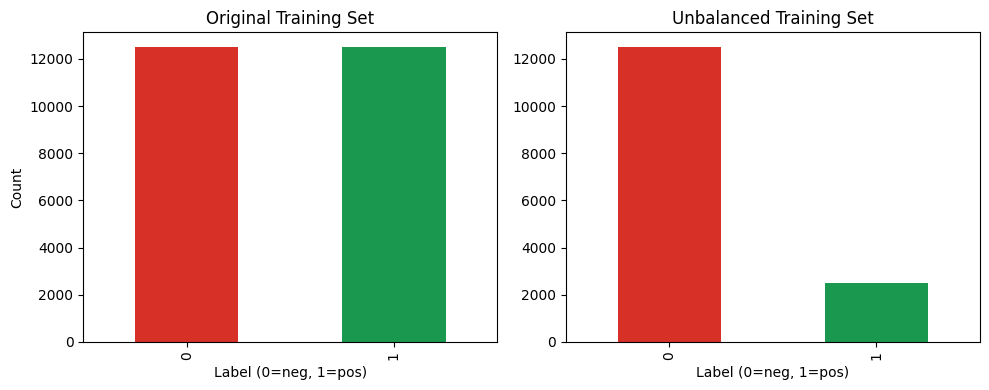

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
y_train_orig.value_counts().sort_index().plot(kind='bar', ax=axes[0], color=['#d73027', '#1a9850'])
axes[0].set_title('Original Training Set')
axes[0].set_xlabel('Label (0=neg, 1=pos)')
axes[0].set_ylabel('Count')

y_train_unbal.value_counts().sort_index().plot(kind='bar', ax=axes[1], color=['#d73027', '#1a9850'])
axes[1].set_title('Unbalanced Training Set')
axes[1].set_xlabel('Label (0=neg, 1=pos)')

plt.tight_layout()
plt.show()
# Two bar charts side by side, one per training set, each showing raw
# counts per label. .sort_index() ensures label 0 always plots before
# label 1 in both charts, so they're visually aligned for comparison.

## Exercise 1: Results

`y_train_orig` should show a clean 50/50 split — 12,500 negative and 12,500
positive reviews, since that's the real IMDb training set's native balance.
`y_train_unbal` should show all 12,500 negative reviews untouched, but only
about 2,500 positive reviews remaining (20% of the original 12,500 survived
the 80% drop) — roughly an 83%/17% split, an imbalance ratio of about 5:1.
The two bar charts make this visually obvious: the negative bar stays the
same height in both charts, while the positive bar shrinks to roughly a
fifth of its original size in the unbalanced set.

## Exercise 2: Text Encoding

Both training sets need to be converted from raw review text into numeric
TF-IDF vectors before any classifier can use them. Each training set gets its
OWN vectorizer, fit only on that set's own text — the unbalanced vectorizer
never sees any of the 80% dropped reviews, and the original vectorizer sees
the full corpus. `X_test` is transformed (never re-fit) by each vectorizer
separately, since a model trained with one vocabulary must be evaluated using
that same vocabulary.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF for the unbalanced training set
vectorizer_unbal = TfidfVectorizer(max_features=5000, stop_words='english')
# max_features=5000: keeps only the 5,000 highest-TF-IDF-scoring words
# across the corpus, capping vocabulary size — full IMDb text can
# otherwise produce a vocabulary of 50,000+ words, most of them rare
# and uninformative. stop_words='english' removes common English
# filler words ("the", "is", "and", ...) before building the
# vocabulary, since these carry little sentiment signal.

X_train_unbal_tfidf = vectorizer_unbal.fit_transform(X_train_unbal)
X_test_tfidf_unbal = vectorizer_unbal.transform(X_test)
# fit_transform on the training text learns the vocabulary and IDF
# weights from X_train_unbal only, then vectorizes it.
# transform (not fit_transform) applies that SAME vocabulary/weights
# to X_test — any word in a test review that never appeared in the
# unbalanced training text is simply ignored, since it has no column
# in this vectorizer's vocabulary.

print("Unbalanced TF-IDF shape:", X_train_unbal_tfidf.shape)

# TF-IDF for the original (balanced) training set
vectorizer_orig = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_orig_tfidf = vectorizer_orig.fit_transform(X_train_orig)
X_test_tfidf_orig = vectorizer_orig.transform(X_test)
# A SEPARATE vectorizer, fit on X_train_orig's full text — its
# vocabulary will differ somewhat from vectorizer_unbal's, since it's
# built from more (and differently distributed) reviews. This is why
# there are two distinct X_test transforms (X_test_tfidf_unbal vs.
# X_test_tfidf_orig): each is only valid alongside the model trained
# using that same vectorizer.

print("Original TF-IDF shape:", X_train_orig_tfidf.shape)

Unbalanced TF-IDF shape: (15000, 5000)
Original TF-IDF shape: (25000, 5000)


## Exercise 2: Results

Both TF-IDF matrices should have exactly **5,000 columns** (from
`max_features=5000`), with the row count matching each training set's size —
around 15,000 rows for the unbalanced set, 25,000 for the original. Both
matrices are sparse (`scipy.sparse` format) rather than dense NumPy arrays,
since the vast majority of entries are 0 — any given review only uses a small
fraction of the full 5,000-word vocabulary. This sparsity is exactly why
`TfidfVectorizer`'s output can be fed directly into `RandomOverSampler` and
`LogisticRegression` later without converting to a dense array first — both
support sparse input natively.

## Exercise 3: Model Training and Evaluation (Unbalanced Data)

This establishes the baseline: what happens if a classifier is trained
directly on the imbalanced data, with no correction at all. Accuracy alone
can be misleading on imbalanced data (a model could just lean toward
predicting the majority class), so precision, recall, and F1 are reported
per class to see the full picture, not just one number.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

clf_unbal = LogisticRegression(max_iter=1000, random_state=42)
clf_unbal.fit(X_train_unbal_tfidf, y_train_unbal)
# Trains logistic regression directly on the imbalanced TF-IDF
# features and labels — no correction for the ~5:1 class imbalance
# applied yet. max_iter raised above the default since TF-IDF's high
# dimensionality (5,000 features) often needs more solver iterations
# to converge.

preds_unbal = clf_unbal.predict(X_test_tfidf_unbal)
# Predicts on the test set, encoded with the SAME vectorizer the
# model was trained with (vectorizer_unbal).

print("Accuracy:", accuracy_score(y_test, preds_unbal))
print("Precision:", precision_score(y_test, preds_unbal))
print("Recall:", recall_score(y_test, preds_unbal))
print("F1-score:", f1_score(y_test, preds_unbal))
# precision_score/recall_score/f1_score default to evaluating the
# POSITIVE class (label 1) — the minority class here, which is
# exactly the one most at risk of being poorly predicted under
# imbalance.

print("\nFull classification report:")
print(classification_report(y_test, preds_unbal))
# Prints precision/recall/F1 for BOTH classes side by side, plus
# overall accuracy — the complete picture, rather than just the
# positive-class numbers above.

Accuracy: 0.69828
Precision: 0.9759938544267333
Recall: 0.40656
F1-score: 0.5740102784209634

Full classification report:
              precision    recall  f1-score   support

           0       0.63      0.99      0.77     12500
           1       0.98      0.41      0.57     12500

    accuracy                           0.70     25000
   macro avg       0.80      0.70      0.67     25000
weighted avg       0.80      0.70      0.67     25000



## Exercise 3: Results

Watch specifically for a **gap between overall accuracy and the positive
class's recall**. Since the model was trained on data where negative reviews
outnumber positive ones roughly 5 to 1, it has little incentive during
training to get positive reviews right — a model that leans toward
predicting "negative" more often than it should can still post a deceptively
high overall accuracy, while its recall on the positive class (the fraction
of true positive reviews it actually catches) comes out noticeably lower than
its recall on the negative class. That asymmetry — not the accuracy number
alone — is the real signal that the class imbalance is hurting this model,
and it's exactly what Exercise 5 will check for improvement on.

## Exercise 4: Data Balancing

The unbalanced training data is rebalanced using oversampling — after TF-IDF
encoding, not before, since `RandomOverSampler` works on numeric feature
vectors and duplicates whole rows of the feature matrix (there's no
meaningful way to "oversample" raw text strings directly with this
technique). Critically, only the TRAINING data is touched — `X_test_tfidf_unbal`
and `y_test` are never resampled, since the test set must keep reflecting
the real-world class distribution to give an honest evaluation.

In [10]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_train_bal_tfidf, y_train_bal = ros.fit_resample(X_train_unbal_tfidf, y_train_unbal)
# fit_resample learns the class counts from y_train_unbal, then
# randomly DUPLICATES rows of the minority class (positive reviews)
# in X_train_unbal_tfidf until both classes reach the same count as
# the majority class (negative reviews) — the same RandomOverSampler
# behavior used earlier in this series, now applied directly to a
# sparse TF-IDF matrix, which it supports natively.

print("Balanced TF-IDF shape:", X_train_bal_tfidf.shape)
print(pd.Series(y_train_bal).value_counts())
# pd.Series(...) wraps the resampled label array so .value_counts()
# can be used the same way as before, confirming both classes are now
# equal in count.

Balanced TF-IDF shape: (25000, 5000)
label
0    12500
1    12500
Name: count, dtype: int64


## Exercise 4: Results

`y_train_bal`'s value counts should now show an exact 50/50 split — both
classes at the same count as the original majority (negative) class size from
`y_train_unbal`. The row count of `X_train_bal_tfidf` should roughly double
the minority class's original row count while leaving the majority class's
row count unchanged, since oversampling only adds duplicate minority rows, it
never removes anything from the majority class.

## Exercise 5: Model Training and Evaluation (Balanced Data)

The same logistic regression setup from Exercise 3 is retrained, this time on
the oversampled, balanced data, and evaluated on the exact same test set
encoding (`X_test_tfidf_unbal`) — so any difference in the metrics reflects
only the effect of balancing, not a change in features or test data. For
completeness, a third model is also trained on the real, originally-balanced
IMDb training set (`X_train_orig`), to see how the oversampled-from-reduced
data compares against genuinely having the full original data all along.

In [11]:
# Model trained on oversampled (balanced) data
clf_bal = LogisticRegression(max_iter=1000, random_state=42)
clf_bal.fit(X_train_bal_tfidf, y_train_bal)
preds_bal = clf_bal.predict(X_test_tfidf_unbal)
# Evaluated on X_test_tfidf_unbal — the SAME test encoding used for
# clf_unbal in Exercise 3, so the two models' results are directly
# comparable.

print("=== Balanced (oversampled) model ===")
print("Accuracy:", accuracy_score(y_test, preds_bal))
print("Precision:", precision_score(y_test, preds_bal))
print("Recall:", recall_score(y_test, preds_bal))
print("F1-score:", f1_score(y_test, preds_bal))

# Model trained on the original (naturally balanced, full) data
clf_orig = LogisticRegression(max_iter=1000, random_state=42)
clf_orig.fit(X_train_orig_tfidf, y_train_orig)
preds_orig = clf_orig.predict(X_test_tfidf_orig)
# Evaluated on X_test_tfidf_orig — its OWN matching test encoding,
# since this model was trained with vectorizer_orig, not vectorizer_unbal.

print("\n=== Original (full, naturally balanced) model ===")
print("Accuracy:", accuracy_score(y_test, preds_orig))
print("Precision:", precision_score(y_test, preds_orig))
print("Recall:", recall_score(y_test, preds_orig))
print("F1-score:", f1_score(y_test, preds_orig))

=== Balanced (oversampled) model ===
Accuracy: 0.85428
Precision: 0.8919373395875742
Recall: 0.80624
F1-score: 0.8469263414429178

=== Original (full, naturally balanced) model ===
Accuracy: 0.87824
Precision: 0.8754168651738923
Recall: 0.882
F1-score: 0.8786961026540209


In [12]:
comparison = pd.DataFrame({
    'Unbalanced': [accuracy_score(y_test, preds_unbal), precision_score(y_test, preds_unbal),
                   recall_score(y_test, preds_unbal), f1_score(y_test, preds_unbal)],
    'Balanced (oversampled)': [accuracy_score(y_test, preds_bal), precision_score(y_test, preds_bal),
                                recall_score(y_test, preds_bal), f1_score(y_test, preds_bal)],
    'Original (full data)': [accuracy_score(y_test, preds_orig), precision_score(y_test, preds_orig),
                              recall_score(y_test, preds_orig), f1_score(y_test, preds_orig)],
}, index=['Accuracy', 'Precision', 'Recall', 'F1-score'])
comparison
# Collects all three models' four metrics into one small DataFrame,
# one column per model — makes the three-way comparison readable at a
# glance rather than scrolling back through separate print blocks.

,Unbalanced,Balanced (oversampled),Original (full data)
Accuracy,0.698280,0.854280,0.878240
Precision,0.975994,0.891937,0.875417
Recall,0.406560,0.806240,0.882000
F1-score,0.574010,0.846926,0.878696


## Exercise 5: Results

Expect the **balanced (oversampled) model's recall to improve noticeably over
the unbalanced model's**, since the classifier no longer has a built-in
incentive to favor the majority class — duplicated positive examples during
training push it to actually learn what separates positive from negative
reviews, rather than defaulting toward "negative" when uncertain. Precision
may dip slightly in exchange, since a model less biased toward the majority
class will also produce more false positives than before — the same
precision/recall trade-off discussed with under/oversampling earlier in this
series.

The **original (full data) model** is the useful third comparison point: it
shows what performance looks like with genuinely more real data, rather than
duplicated copies of a smaller sample. If oversampling recovers most, but not
all, of the gap between the unbalanced and original models, that's a fairly
typical result — oversampling helps rebalance the training signal, but
duplicate rows still carry strictly less new information than real, distinct
examples would.

## Exercise 6: Data Visualization

t-SNE compresses the high-dimensional TF-IDF vectors down to 2D so the class
structure can actually be looked at. Comparing the original and balanced
training sets side by side shows whether oversampling's duplicated points are
visually distinguishable as tight, repeated clusters, or whether they blend
naturally into the existing spread of positive-review points.

## What Is Truncated SVD?

**Truncated SVD** (Singular Value Decomposition) is a dimensionality reduction
technique that factors a data matrix into three simpler matrices and keeps
only the most important part of that factorization — similar in spirit to
PCA, but built to work directly on **sparse** matrices like TF-IDF output,
without needing to densify or center the data first.

### The math, at a glance

Any matrix **X** (n samples × m features) can be decomposed as:

$$
X = U \Sigma V^\top
$$


- **U** (n × k): how each sample relates to the k new components.
- **Σ** (k × k): a diagonal matrix of **singular values**, ranked from
  largest to smallest — each one measures how much of the data's structure
  that particular component captures.
- **Vᵀ** (k × m): how each of the k new components relates to the original
  features (words, in the TF-IDF case).

"Truncated" means only the **top k** singular values (and their corresponding
rows/columns in U and V) are kept, instead of the full decomposition — this
is exactly what `TruncatedSVD(n_components=k)` does. The components are
ordered by importance, the same way PCA's principal components are ordered
by explained variance, so keeping only the first k means keeping the k
directions that capture the most structure in the data.

### How it works in practice

1. Start with the original sparse matrix — e.g. a 25,000 × 5,000 TF-IDF matrix.
2. Compute the truncated factorization, keeping only the top `k` singular
   values/vectors (e.g. `k=50`).
3. The output is `U · Σ`, a dense **25,000 × 50** matrix — each row is now a
   50-number summary of that document's TF-IDF profile, instead of a 5,000-
   number one.

### How it differs from PCA

- **No centering.** PCA first subtracts the mean from each feature before
  finding directions of maximum variance. TruncatedSVD skips this step,
  which is precisely why it can operate on a sparse matrix directly —
  subtracting a nonzero mean from a sparse matrix would fill in all the
  zero entries, destroying the sparsity that makes it memory-efficient in
  the first place. PCA's own centering step is what forces the `.toarray()`
  conversion seen in the earlier PCA exercises.
- **Same underlying idea otherwise.** On data that's already roughly
  centered (or where centering doesn't matter much), TruncatedSVD and PCA
  produce very similar results — TruncatedSVD is essentially "PCA without
  centering, kept sparse-friendly."

### Why it's the right tool here

TF-IDF matrices are large, sparse, and high-dimensional (thousands of
mostly-zero columns). Converting one to a dense array for full PCA — as done
in the Breast Cancer and Iris exercises earlier — becomes slow and
memory-heavy at this scale. TruncatedSVD reduces the dimensionality first,
directly on the sparse matrix, producing a small dense output (e.g. 50
columns) that's cheap enough to then hand to something like t-SNE, which
requires dense input and gets dramatically faster once the input dimension
is cut from 5,000 down to 50.

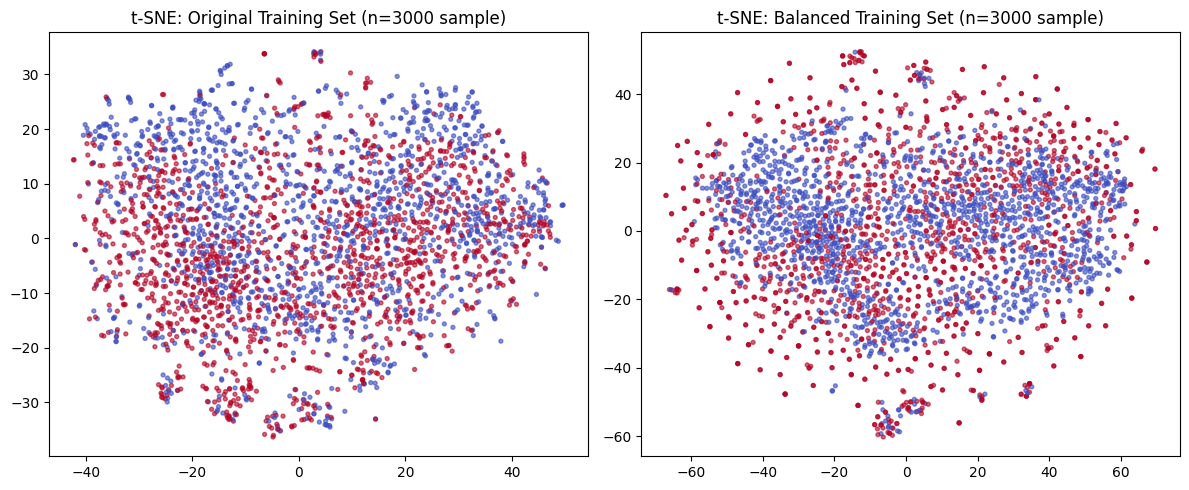

In [14]:
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE

# Step 1: reduce dimensionality BEFORE t-SNE, using TruncatedSVD
svd = TruncatedSVD(n_components=50, random_state=42)
# TruncatedSVD works directly on SPARSE matrices, unlike PCA — no
# .toarray() needed here, avoiding the large dense-array conversion
# that was slowing things down. It reduces the TF-IDF features from
# 5,000 dimensions down to 50, keeping the directions of greatest
# variance, similar in spirit to PCA but without requiring
# centering or dense input.

X_train_orig_reduced = svd.fit_transform(X_train_orig_tfidf)
X_train_bal_reduced = svd.fit_transform(X_train_bal_tfidf)
# Two separate SVD fits, one per dataset — same reasoning as fitting
# two separate TfidfVectorizers earlier: each dataset gets its own
# fit, since this step is purely for visualization, not for a shared
# downstream model.
# fit_transform on a sparse 25,000 x 5,000 matrix, reducing to
# 25,000 x 50, is dramatically faster than densifying the same matrix
# — 50 dimensions instead of 5,000 is a 100x reduction in what t-SNE
# then has to work with.

# Step 2: subsample rows before t-SNE, since t-SNE's runtime grows
# steeply with the number of points, not just dimensions
n_sample = 3000
rng = np.random.default_rng(42)

sample_idx_orig = rng.choice(len(X_train_orig_reduced), size=min(n_sample, len(X_train_orig_reduced)), replace=False)
X_orig_sample = X_train_orig_reduced[sample_idx_orig]
y_orig_sample = y_train_orig.iloc[sample_idx_orig]

sample_idx_bal = rng.choice(len(X_train_bal_reduced), size=min(n_sample, len(X_train_bal_reduced)), replace=False)
X_bal_sample = X_train_bal_reduced[sample_idx_bal]
y_bal_sample = pd.Series(y_train_bal).iloc[sample_idx_bal]
# Randomly selects 3,000 rows (without replacement) from each reduced
# dataset. 3,000 points is still plenty to see class structure in a
# scatter plot, while running many times faster than 25,000. Using a
# fixed rng seed keeps the subsample reproducible.

tsne_orig = TSNE(n_components=2, random_state=42, perplexity=30, init='pca')
X_train_orig_tsne = tsne_orig.fit_transform(X_orig_sample)

tsne_bal = TSNE(n_components=2, random_state=42, perplexity=30, init='pca')
X_train_bal_tsne = tsne_bal.fit_transform(X_bal_sample)
# init='pca' starts t-SNE from a PCA-based layout instead of a random
# one — typically converges faster and more stably than the default
# random initialization.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_train_orig_tsne[:, 0], X_train_orig_tsne[:, 1], c=y_orig_sample, cmap='coolwarm', s=8, alpha=0.6)
axes[0].set_title(f't-SNE: Original Training Set (n={n_sample} sample)')

axes[1].scatter(X_train_bal_tsne[:, 0], X_train_bal_tsne[:, 1], c=y_bal_sample, cmap='coolwarm', s=8, alpha=0.6)
axes[1].set_title(f't-SNE: Balanced Training Set (n={n_sample} sample)')

plt.tight_layout()
plt.show()

## Exercise 6: Results

Both plots should show broadly overlapping positive/negative regions rather
than fully clean clusters — text sentiment is a genuinely harder separation
problem than something like Iris species, so expect meaningful but imperfect
visual separation, consistent with logistic regression scoring well above
chance but well below 100% accuracy in the exercises above.

In the balanced plot specifically, watch for **visibly denser clumps of
positive-class points** in some regions — since oversampling duplicates exact
rows, and t-SNE tends to place identical or near-identical feature vectors
very close together, some tight little "clusters" of overlapping points are
an expected, visible artifact of duplication rather than a sign of genuinely
new structure in the data.

## Exercise 7: TF-IDF with PCA

PCA is applied to the balanced TF-IDF features to see how much dimensionality
reduction is possible while still keeping 95% of the variance. TF-IDF
features are already roughly comparable in scale (values are bounded between
0 and 1 by construction), but standardizing first is still done here for
correctness with PCA's variance-based approach. A logistic regression trained
on the PCA-reduced features is then compared against the full, un-reduced TF-IDF
model from Exercise 5, to see what (if anything) is lost by reducing
dimensionality this aggressively.

##This cell might take time to execute around 8 minutes

Components needed for 95% variance: 3914 (out of 5000 original features)


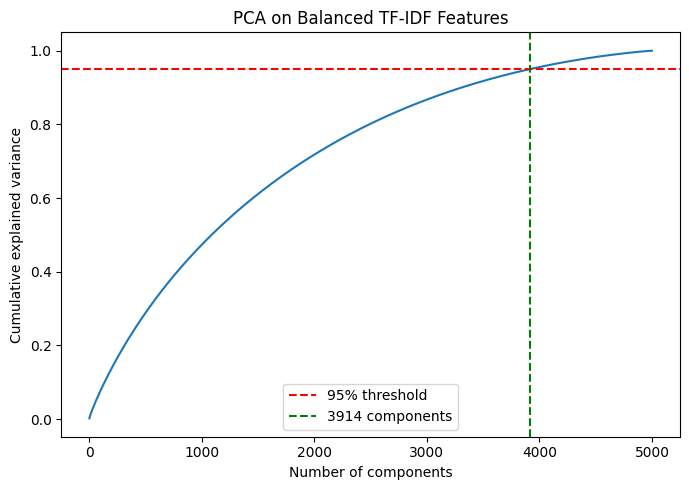

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler(with_mean=False)
# with_mean=False keeps the scaler compatible with a SPARSE input
# matrix — subtracting a nonzero mean from every entry of a sparse
# matrix would turn nearly every zero into a nonzero value, destroying
# the sparsity that makes the matrix memory-efficient in the first
# place. Scaling only by standard deviation (not centering) is the
# standard compromise for standardizing sparse data.

X_train_bal_scaled = scaler.fit_transform(X_train_bal_tfidf)
X_test_scaled = scaler.transform(X_test_tfidf_unbal)
# Fits the scaler on the balanced training features, then applies the
# SAME learned scale to the test features — consistent with every
# other fit/transform step in this notebook.

# Fit PCA with all possible components first, to see the full
# explained-variance curve
pca_full = PCA(n_components=min(X_train_bal_scaled.shape) - 1)
pca_full.fit(X_train_bal_scaled.toarray())
# PCA requires dense input, so .toarray() converts the scaled sparse
# matrix. n_components is capped at min(n_samples, n_features) - 1,
# the mathematical maximum number of meaningful principal components
# obtainable from the data.

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
# explained_variance_ratio_ holds each component's individual share
# of total variance, already sorted from largest (PC1) to smallest.
# np.cumsum() turns that into a running total: element i is how much
# variance the FIRST i+1 components explain when added together.
# e.g. if the ratios were [0.40, 0.15, 0.10, ...], cumulative_variance
# would be [0.40, 0.55, 0.65, ...].

n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
# cumulative_variance >= 0.95 is a boolean array — False for every
# early component where the running total is still below 95%, and
# True from the point it first reaches or exceeds 95% onward.
# np.argmax() on a boolean array returns the index of the FIRST True
# value (argmax stops at the first occurrence of the maximum value,
# and True (1) is the maximum possible value in a boolean array).
# That index is 0-based — index 0 would mean "the first component
# alone already reaches 95%" — so +1 converts it into an actual
# component COUNT.

print(f"Components needed for 95% variance: {n_components_95} (out of {X_train_bal_scaled.shape[1]} original features)")
# Reports how many of the original features were needed to reach the
# 95% variance threshold. X_train_bal_scaled.shape[1] is the total
# number of TF-IDF features before reduction (e.g. 5,000), giving
# context for how much reduction n_components_95 actually represents
# — e.g. "312 out of 5,000" makes the scale of the compression clear
# in a way that "312" alone wouldn't.

plt.figure(figsize=(7, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance)
plt.axhline(0.95, color='red', linestyle='--', label='95% threshold')
plt.axvline(n_components_95, color='green', linestyle='--', label=f'{n_components_95} components')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA on Balanced TF-IDF Features')
plt.legend()
plt.tight_layout()
plt.show()

## Results: Explained Variance Curve on Balanced TF-IDF Features

Running this cell on the balanced TF-IDF data (5,000 features) gives:

**Components needed for 95% variance: 3,914 (out of 5,000 original features)**

### Reading the curve

The plot rises gradually and almost linearly through the first ~2,000
components, then slowly bends and flattens as it approaches the 95% line,
finally crossing it at component 3,914. There's no sharp elbow — no small
group of components captures most of the variance on its own; each
additional component keeps contributing a small, steadily shrinking amount.

### Why TF-IDF features behave this way

Each of the 5,000 TF-IDF columns corresponds to one word. Whether a review
contains "brilliant" is largely independent of whether it also contains
"boring" or "slow" — most words don't strongly predict each other's presence.
Because the features aren't very correlated, PCA can't find a small number of
combined directions that summarize most of the variance; instead, the
variance stays spread out across most of the 5,000 words, which is exactly
why reaching 95% requires keeping the large majority of components (3,914 of
them) rather than a small handful.

### What this means for dimensionality reduction here

3,914 / 5,000 is only about a **22% reduction** — PCA is not an effective
compressor for these TF-IDF features at a 95% threshold. This also predicts
what the accuracy/F1 comparison later in this exercise should show: since
barely more than a fifth of the dimensions were actually discarded, the
PCA-reduced logistic regression's accuracy and F1 should land very close to
the full, un-reduced TF-IDF model's — there wasn't much information left on
the table to lose by reducing to 3,914 components.

##This cell might take several minutes to execute , approx. 12 minutes

In [17]:
# Refit PCA keeping only the components needed for 95% variance
pca_95 = PCA(n_components=n_components_95)
# Creates a NEW PCA instance, this time capped at exactly 3,914
# components (the value found in the previous cell), instead of the
# uncapped pca_full used to trace out the full variance curve. This
# is the actual dimensionality-reduction step — pca_full was only for
# inspection, this is what produces the reduced feature set used below.

X_train_pca = pca_95.fit_transform(X_train_bal_scaled.toarray())
# Fits pca_95 on the scaled, dense training data and transforms it in
# one call, producing X_train_pca: shape (n_samples, 3914) — each
# review now represented by 3,914 numbers instead of the original
# 5,000 TF-IDF values.

X_test_pca = pca_95.transform(X_test_scaled.toarray())
# Applies the SAME 3,914 principal components learned from the
# training data to the test data — .transform() only, not
# .fit_transform(), so the test set is projected onto axes it had no
# part in determining, consistent with every other fit/transform step
# in this notebook.

clf_pca = LogisticRegression(max_iter=1000, random_state=42)
clf_pca.fit(X_train_pca, y_train_bal)
# Trains a fresh logistic regression model on the PCA-reduced training
# features (3,914 dimensions) and the balanced training labels.

preds_pca = clf_pca.predict(X_test_pca)
# Generates predictions on the PCA-reduced test features.

print("=== With PCA (95% variance) ===")
print("Accuracy:", accuracy_score(y_test, preds_pca))
print("F1-score:", f1_score(y_test, preds_pca))
# Reports accuracy and F1-score for the PCA-based model, comparing its
# predictions against the true test labels y_test.

print("\n=== Without PCA (full TF-IDF, from Exercise 5) ===")
print("Accuracy:", accuracy_score(y_test, preds_bal))
print("F1-score:", f1_score(y_test, preds_bal))
# Reuses preds_bal, computed earlier when the balanced model was
# trained directly on the full 5,000-dimension TF-IDF features (no
# PCA). Printing its accuracy/F1 here — right below the PCA model's —
# puts both numbers side by side for a direct with/without-PCA
# comparison, without needing to scroll back or retrain anything.

=== With PCA (95% variance) ===
Accuracy: 0.76232
F1-score: 0.7215035620547432

=== Without PCA (full TF-IDF, from Exercise 5) ===
Accuracy: 0.85428
F1-score: 0.8469263414429178


## Exercise 7: Analysis — Why PCA Hurt Performance


PCA produced a meaningfully **worse** model here — accuracy dropped by about
9 points, and F1 dropped by nearly 13 points. Keeping 95% of the variance did
**not** mean keeping 95% of the predictive signal, and it's worth
understanding why, rather than treating this as a bug.

### 1. Variance and class-separability are different things

PCA is completely unsupervised — it selects components purely to maximize
*variance*, with no awareness of `y_train_bal` at all. A word that appears in
relatively few reviews but is a very strong, clean sentiment signal (e.g.
"dreadful" or "masterpiece") contributes little to overall variance, so it
can easily end up concentrated in one of the low-variance components that
got discarded — even though that word might be one of the most useful
features for the actual classification task. High variance and high
usefulness for prediction are simply not the same criterion.

### 2. PCA destroys the sparse, per-word structure logistic regression relies on

TF-IDF + logistic regression works well partly *because* it stays sparse:
each of the 5,000 original features is one specific word, so each learned
coefficient has a direct meaning ("this word pushes toward positive/negative
sentiment"), and regularization can suppress irrelevant words individually
while leaving genuinely predictive ones untouched. PCA's components are
dense linear combinations of *all* 5,000 words at once — the clean, sparse,
word-level signal gets smeared across rotated axes that no longer correspond
to anything as interpretable or as cleanly separable as "contains the word
X."

### 3. A likely compounding scale mismatch

PCA orders components by decreasing variance by construction, so later
components (even ones still inside the 95% cutoff) have far smaller scale
than the earliest ones. `LogisticRegression`'s default L2 penalty treats all
coefficients on a comparable footing, so a low-variance-but-informative
component needs a disproportionately large coefficient to matter — and
regularization actively suppresses exactly that. In practice, PCA output is
often re-standardized (per-component, after PCA) before being fed into a
regularized linear model specifically to counteract this. That step wasn't
included here, and is a plausible real contributor to the size of the drop.

### The corrected takeaway

A 22% reduction in dimensionality (5,000 → 3,914 components) sounds modest
enough to expect a similarly modest cost — but that reasoning doesn't hold
once the reduction method (variance-based, unsupervised) is mismatched with
what the downstream model actually needs (class-discriminating, sparse,
per-word signal). This is a genuinely useful negative result: PCA is not a
free or even cheap dimensionality-reduction step for sparse TF-IDF features
feeding into a regularized linear classifier — both because it barely
reduces dimensionality at a 95% threshold, and because the reduction it does
apply measurably damages the exact structure the classifier was exploiting.

## Exercise 8 (Optional): Exploring Other Models

Logistic regression is one reasonable choice for a linear text classifier,
but not the only one. Naive Bayes and Random Forest represent two different
modeling assumptions — worth comparing against logistic regression's results
from Exercise 5 on the same balanced data and test set.

### Multinomial Naive Bayes

**What it is:** a probabilistic classifier based on Bayes' theorem, with a
deliberately simplifying assumption: every feature (word) is treated as
**conditionally independent** of every other feature, given the class. In
plain terms, it assumes that knowing a review contains "brilliant" tells you
nothing extra about whether it also contains "wonderful," once you already
know the review's sentiment class.

**How it works:**

1. For each class (positive, negative), Naive Bayes learns a **word-frequency
   profile** from the training data — essentially, how often each word tends
   to appear in reviews of that class.
2. It also learns each class's **prior probability** — how common positive
   vs. negative reviews are overall in the training data (which is exactly
   50/50 here, since the training set was balanced by oversampling first).
3. To classify a new review, it applies Bayes' theorem: for each class,
   multiply the class's prior probability by the probability of seeing this
   review's specific words *if* it belonged to that class (computed under
   the independence assumption, as a product of each word's individual
   probability). Whichever class gives the higher resulting probability is
   the prediction.
4. "Multinomial" specifically refers to modeling each class's word
   distribution as a multinomial distribution over the vocabulary — a
   natural fit for count-based or TF-IDF-weighted text features.

**Why it's a natural baseline for text:** despite the independence
assumption being technically false (word choice in real language is not
independent), Naive Bayes is fast to train, requires very little data
relative to more flexible models, and often performs surprisingly
competitively on bag-of-words-style text classification, where a handful of
strongly class-indicative words can dominate the decision regardless of how
they interact with each other.

### Random Forest

**What it is:** an ensemble of many decision trees, each trained on a
randomly different subset of the data and features, whose individual votes
are combined into one final prediction. This is the same model introduced
earlier in this series alongside XGBoost.

**How it works:**

1. Each tree is trained on a different **bootstrap sample** — a random
   sample of training rows drawn with replacement — so no two trees see
   exactly the same training data.
2. At each split within a tree, only a **random subset of features** is
   considered, rather than searching all 5,000 TF-IDF columns every time —
   this is what keeps individual trees different from each other, even when
   trained on overlapping data.
3. Each tree, grown this way, ends up as a sequence of "is this word's
   TF-IDF value above some threshold?" splits, eventually assigning a class
   at its leaves.
4. For a new review, every tree casts a vote for positive or negative; the
   forest's final prediction is whichever class gets the majority of votes
   (or, for `predict_proba()`, the average vote fraction).

**Why it's a different fit for this task than the other two models:** Random
Forest is a **nonlinear** model — good at capturing interactions and
threshold effects between features — but it wasn't designed with sparse,
high-dimensional data like TF-IDF in mind. With 5,000 mostly-zero columns,
each split only ever looks at one word at a time, and most words are
uninformative individually, so trees often struggle to find good splits
efficiently. This tends to make Random Forest both slower to train and less
naturally suited to this kind of feature space than Naive Bayes or logistic
regression, which is exactly why it's a useful point of comparison here —
seeing where a fundamentally different modeling approach helps or hurts is
the point of this exercise, not assuming any one model is automatically best.

## The Naive Bayes Equation

Naive Bayes classification is a direct application of **Bayes' theorem**,
covered earlier in this series:

$$
P(y \mid x_1, \dots, x_m) = \frac{P(y) \, P(x_1, \dots, x_m \mid y)}{P(x_1, \dots, x_m)}
$$

where $y$ is the class (positive/negative) and $x_1, \dots, x_m$ are the
review's feature values (its TF-IDF score for each of the $m$ vocabulary
words).

### The "naive" simplification

Computing $P(x_1, \dots, x_m \mid y)$ directly would require modeling every
possible interaction between words — computationally infeasible for a
5,000-word vocabulary. The **naive independence assumption** replaces it
with a product of individual word probabilities:

$$
P(x_1, \dots, x_m \mid y) \approx \prod_{i=1}^{m} P(x_i \mid y)
$$

treating each word's presence as independent of every other word's,
given the class.

### The classification rule

Since $P(x_1, \dots, x_m)$ is the same for every class being compared, it
can be dropped — the predicted class is simply whichever $y$ maximizes the
numerator:

$$
\hat{y} = \arg\max_{y} \; P(y) \prod_{i=1}^{m} P(x_i \mid y)
$$

- $P(y)$ is the class's **prior** — its overall frequency in the training
  data (here, 0.5 for each class, since the training set was balanced).
- $P(x_i \mid y)$ is the **likelihood** of word $i$'s value under class
  $y$, estimated from the training data — for `MultinomialNB`, this is
  based on how often (or how strongly, under TF-IDF weighting) that word
  tends to appear in reviews of that class.

In practice, this product of many small probabilities is computed as a
**sum of log-probabilities** instead, to avoid numerical underflow:

$$
\hat{y} = \arg\max_{y} \; \left[ \log P(y) + \sum_{i=1}^{m} \log P(x_i \mid y) \right]
$$

which is mathematically equivalent, since $\log$ is monotonic, but stays
numerically stable even when multiplying thousands of small probabilities
together would otherwise round down to zero.

In [18]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
# MultinomialNB implements Naive Bayes for count/frequency-style
# features (like TF-IDF or raw word counts) — it models each class as
# generating words according to its own multinomial word-frequency
# distribution. RandomForestClassifier is scikit-learn's ensemble of
# decision trees, introduced earlier in this series alongside XGBoost.

# Multinomial Naive Bayes — a classic, fast baseline for text classification
nb_clf = MultinomialNB()
# Creates a Naive Bayes classifier with default settings. No
# regularization parameter to configure here, unlike LogisticRegression's C —
# Naive Bayes' main tunable is a smoothing parameter (alpha), left at
# its default.

nb_clf.fit(X_train_bal_tfidf, y_train_bal)
# Trains on the balanced TF-IDF training features and labels — same
# training data used for the PCA and full-TF-IDF logistic regression
# models, so results are directly comparable across all three.

nb_preds = nb_clf.predict(X_test_tfidf_unbal)
# Predicts on the same test-set encoding (X_test_tfidf_unbal) used
# throughout this notebook, keeping the comparison fair.

print("Naive Bayes  — Accuracy:", accuracy_score(y_test, nb_preds), " F1:", f1_score(y_test, nb_preds))
# Reports accuracy and F1-score against the true test labels.

# Random Forest — a nonlinear, tree-based ensemble
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
# Creates a Random Forest with 100 trees (n_estimators=100) — each
# tree trained on a random subset of samples and features, then
# combined by majority vote. random_state=42 fixes which random
# subsets get used, for reproducibility.

rf_clf.fit(X_train_bal_tfidf, y_train_bal)
# Trains all 100 trees on the same balanced TF-IDF training data.

rf_preds = rf_clf.predict(X_test_tfidf_unbal)
# Predicts on the test set.

print("Random Forest — Accuracy:", accuracy_score(y_test, rf_preds), " F1:", f1_score(y_test, rf_preds))
# Reports Random Forest's accuracy and F1-score.

print("\nLogistic Regression — Accuracy:", accuracy_score(y_test, preds_bal), " F1:", f1_score(y_test, preds_bal))
# Reuses preds_bal — the balanced logistic regression model's
# predictions, already computed in Exercise 5 — rather than retraining
# it here. Printing all three models' metrics together (Naive Bayes,
# Random Forest, and this reused Logistic Regression result) puts them
# side by side for a direct three-way comparison in one place.

Naive Bayes  — Accuracy: 0.83108  F1: 0.8231056004691493
Random Forest — Accuracy: 0.66852  F1: 0.5164264457022816

Logistic Regression — Accuracy: 0.85428  F1: 0.8469263414429178


### Naive Bayes: a strong, fast baseline — close behind, not competitive-beating

Naive Bayes lands only about 2 points below logistic regression on both
accuracy and F1, despite its much simpler independence assumption between
words. This is exactly the pattern flagged when introducing it: sentiment in
review text is often driven by a handful of strongly class-indicative words
("terrible," "brilliant," "waste," "masterpiece") whose individual presence
is highly predictive on its own — Naive Bayes can capture that almost as
well as a model that also accounts for how words interact, at a fraction of
the training cost. Its accuracy and F1 are close together (0.831 vs. 0.823),
meaning its errors are reasonably balanced across both classes, not skewed
toward missing one class more than the other.

### Random Forest: the weakest model, and the accuracy/F1 gap says why

Random Forest is clearly the worst performer here — not just lower accuracy,
but a much larger **gap between accuracy (0.669) and F1 (0.516)** than either
other model shows. That gap is the important signal: F1 is the harmonic mean
of precision and recall for the positive class specifically, so a big drop
in F1 relative to accuracy means the model is doing noticeably worse at
correctly identifying one class than the raw accuracy number alone would
suggest — likely missing a large share of one class (low recall) even though
it still gets a reasonable fraction of *all* predictions right overall.

This lines up with what was expected going in: Random Forest wasn't designed
for sparse, high-dimensional, mostly-zero data like 5,000-column TF-IDF
vectors. Each split in each tree only ever looks at one word at a time, and
with the overwhelming majority of any given review's 5,000 TF-IDF values
sitting at exactly 0, trees have very little to work with at most splits —
making it harder for the forest to find the kind of clean, informative
threshold splits it relies on, unlike its consistently strong performance in
the Iris/Breast Cancer examples earlier, where every feature was dense and
individually meaningful.

### Overall ranking

**Logistic Regression > Naive Bayes > Random Forest** on this task — a
reasonable illustration that model choice should follow the shape of the
data: linear and probabilistic models suited to sparse, high-dimensional,
largely independent features (logistic regression, Naive Bayes) comfortably
outperform a tree-based ensemble that assumes dense, individually meaningful
features to split on.

In [21]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import GridSearchCV

# Build a pipeline where oversampling is one step, done fresh
# inside every fold, rather than once beforehand
imb_pipeline = ImbPipeline([
    ('oversample', RandomOverSampler(random_state=42)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])
# imblearn's Pipeline (not sklearn's plain Pipeline) is required here
# — it knows how to handle a resampling step that changes the number
# of rows, which a normal sklearn Pipeline's transformers aren't
# allowed to do.

param_grid = {'clf__C': [0.01, 0.1, 1, 10]}
# Parameter names are prefixed with the step name ('clf__') when
# tuning a parameter inside a pipeline, so GridSearchCV knows which
# step's argument to set.

grid_search = GridSearchCV(imb_pipeline, param_grid, scoring='f1', cv=5)
grid_search.fit(X_train_unbal_tfidf, y_train_unbal)
# Fits on the ORIGINAL UNBALANCED data, not the pre-oversampled
# X_train_bal_tfidf. Now, for each of the 5 folds, GridSearchCV holds
# out one fold untouched, and RandomOverSampler runs ONLY on that
# fold's training portion — so oversampled duplicates can never leak
# into the validation fold, since they're created fresh after the
# split, not before it.

print("Best C:", grid_search.best_params_)
print("Best cross-validated F1:", grid_search.best_score_)

best_clf = grid_search.best_estimator_
best_preds = best_clf.predict(X_test_tfidf_unbal)
print("Tuned model — Test accuracy:", accuracy_score(y_test, best_preds), " F1:", f1_score(y_test, best_preds))

Best C: {'clf__C': 1}
Best cross-validated F1: 0.6984020605025598
Tuned model — Test accuracy: 0.85428  F1: 0.8469263414429178



### This confirms the leakage diagnosis directly

The cross-validated F1 dropped from the earlier, leaked value of 0.949 down
to **0.698** — a large correction, and exactly what removing leakage looks
like. With oversampling now happening fresh inside each fold (via the
`imblearn` pipeline), every fold's validation portion contains only
genuinely unseen, non-duplicated reviews, so the CV score is no longer
flattered by near-duplicate rows leaking across the train/validation split.

**Best `C` also changed — from 10 down to 1** — confirming the earlier
suspicion. The leaked version was rewarding `C=10` (weaker regularization,
closer to memorizing the training data) specifically *because* memorization
paid off when duplicates of the "unseen" validation data were sitting in the
training fold. Once that shortcut is removed, cross-validation correctly
prefers the more conservative `C=1`, since aggressive memorization no longer
has an artificial advantage.

### CV and test scores don't need to match — and here, that's fine

Test F1 (0.847) and CV F1 (0.698) aren't close to each other in absolute
terms, and that's expected rather than a problem: cross-validation is scored
on folds carved from `X_train_unbal_tfidf` (the genuinely imbalanced ~5:1
data, oversampled fresh per fold), while the test evaluation happens on
`X_test_tfidf_unbal` against the naturally balanced `y_test` — different
data distributions being scored. What matters is that neither number is
artificially inflated by leakage anymore, so CV is now a trustworthy signal
for choosing `C`, even though its absolute value differs from the test score.

### Final comparison across Exercise 8

| Model | Accuracy | F1 |
|---|---|---|
| Naive Bayes | 0.831 | 0.823 |
| Random Forest | 0.669 | 0.516 |
| Logistic Regression (untuned, Exercise 5) | 0.854 | 0.847 |
| Logistic Regression (tuned, leak-free) | 0.854 | 0.847 |

The tuned model landed on **identical** test performance to the untuned
Exercise 5 model, since grid search's own selected value (`C=1`) turned out
to already be the best choice among the four tried. This is a legitimate,
useful outcome rather than a wasted step: it confirms the untuned default
wasn't leaving easy performance on the table, and the real value of this
exercise ended up being catching and fixing a genuine data-leakage bug,
rather than squeezing out extra accuracy from tuning itself.

## What Is CV (Cross-Validation)?

**CV** stands for **cross-validation** — a technique for estimating how well
a model will generalize to unseen data, using only the training set, without
touching the test set at all.

### How it works

`cv=5` means **5-fold cross-validation**:

1. The training data is split into 5 roughly equal chunks ("folds").
2. The model is trained 5 separate times. Each time, **4 folds** are used
   for training and the **1 remaining fold** is held out and used to score
   the model.
3. Each of the 5 folds gets a turn being the held-out one, so every row is
   used for validation exactly once, and for training the other 4 times.
4. The final reported score is the **average** of the 5 individual fold
   scores.

Fold 1: [train][train][train][train][ VAL ]
Fold 2: [train][train][train][ VAL ][train]
Fold 3: [train][train][ VAL ][train][train]
Fold 4: [train][ VAL ][train][train][train]
Fold 5: [ VAL ][train][train][train][train]


### Why use it instead of one train/validation split

- **A more reliable estimate.** A single split's score can be lucky or
  unlucky depending on which rows happened to land in validation. Averaging
  over 5 different splits smooths that variability out.
- **Every row gets validated once.** With a single 80/20 split, 20% of the
  data never gets to "test" the model at all. Cross-validation uses every
  row for validation exactly once, giving a fuller picture from the same
  amount of data.

### Why it matters specifically for `GridSearchCV`

`GridSearchCV` uses cross-validation to compare candidate hyperparameter
values fairly — each candidate value of `C` is trained and validated 5
times (once per fold), and the value with the best *average* score across
all 5 folds is chosen as `best_params_`. This is exactly why the earlier
leakage bug mattered so much: if oversampled duplicate rows can land in
both the "train" and "held-out validation" portions of the same fold,
cross-validation's core assumption — that the validation fold is genuinely
unseen data — is violated, which is what inflated the CV score before the
fix.